# Fig 3b — Classification performance vs model size

Scatter plot of mean AUPRC (default: **MIL** aggregation, 5-fold CV) against foundation-model parameter count.
Set `STRATEGY` to `'vote'` or `'avg'` in the config cell to switch aggregation.

Zero-parameter baselines (HVG, PCA [20], scVI) are shown as subtle dashed horizontal reference lines.
Finetune / continue / Full variants and PCA [50]/[100] are excluded from the comparison.

This version uses:

- a colorblind-friendly, publication-oriented palette;
- log-scaled parameter counts;
- automatic label adjustment with `adjustText` when available;
- a built-in fallback label-repulsion routine when `adjustText` is not installed;
- compact label text to reduce clutter.

Data source: `scFM_eval/results/classification.metrics.csv`  
Parameter counts were verified from local checkpoints where available (see `MODEL_PARAM_SIZES` below).


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path('../../').resolve()
METRICS_PATH = REPO_ROOT / 'results' / 'classification.metrics.csv'
PLOTS_DIR = Path('./plots')
METRICS_OUT_DIR = Path('./metrics')
PLOTS_DIR.mkdir(exist_ok=True)
METRICS_OUT_DIR.mkdir(exist_ok=True)

# Aggregation strategy: 'MIL' (default), 'vote', or 'avg'
STRATEGY = 'MIL'


In [20]:
# Parameter counts (absolute numbers).
# Verified from /home/haitham/mnt/MODELS/ checkpoints unless noted.
MODEL_PARAM_SIZES: dict[str, int] = {
    # Baselines — no pretrained transformer backbone
    'HVG': 0,
    'PCA [20]': 0,
    'PCA [50]': 0,
    'PCA [100]': 0,
    'scVI': 0,
    # Geneformer (pytorch_model.bin / model.safetensors)
    'GF-V1': 16_825_252,          # Geneformer-V1-10M/pytorch_model.bin (named "10M")
    'GF-V1 [finetune]': 16_825_252,
    'GF-V2': 104_387_072,         # Geneformer-V2-104M/model.safetensors
    'GF-V2 [cancer]': 104_387_072,
    'GF-V2 [finetune]': 104_387_072,
    'GF-V2-Deep': 316_355_328,    # Geneformer-V2-316M/model.safetensors
    # scGPT
    'scGPT': 51_326_464,          # scGPT_human/best_model.pt
    'scGPT [cancer]': 51_326_464, # scGPT_cancer/best_model.pt
    # Other foundation models
    'scFoundation': 100_000_000,  # published model size (100M)
    'CellPLM': 82_360_031,        # 20231027_85M.best.ckpt (marketed as 85M)
    'SCimiarity': 31_152_262,     # model_v1.1/encoder.ckpt
    'Nicheformer': 49_302_040,    # nicheformer.ckpt (Nature Methods: 49.3M)
    'scConcept': 30_000_000,      # Corpus-30M / corpus40M-model30M (HF card)
    'STATE': 600_000_000,         # arcinstitute/SE-600M (marketed size)
}

In [21]:
MODEL_PARAM_SOURCES: dict[str, str] = {
    'HVG': 'baseline (no pretrained backbone)',
    'PCA [20]': 'baseline (no pretrained backbone)',
    'PCA [50]': 'baseline (no pretrained backbone)',
    'PCA [100]': 'baseline (no pretrained backbone)',
    'scVI': 'baseline (no pretrained backbone)',
    'GF-V1': 'Geneformer-V1-10M/pytorch_model.bin (checkpoint count; marketed as 10M)',
    'GF-V1 [finetune]': 'same architecture as GF-V1',
    'GF-V2': 'Geneformer-V2-104M/model.safetensors',
    'GF-V2 [cancer]': 'Geneformer-V2-104M/model.safetensors',
    'GF-V2 [finetune]': 'same architecture as GF-V2',
    'GF-V2-Deep': 'Geneformer-V2-316M/model.safetensors',
    'scGPT': 'scGPT_human/best_model.pt',
    'scGPT [cancer]': 'scGPT_cancer/best_model.pt',
    'scFoundation': 'published model size (100M)',
    'CellPLM': '20231027_85M.best.ckpt (marketed as 85M)',
    'SCimiarity': 'model_v1.1/encoder.ckpt',
    'Nicheformer': 'nicheformer.ckpt (Nature Methods: 49.3M)',
    'scConcept': 'Corpus-30M / corpus40M-model30M (HF card)',
    'STATE': 'arcinstitute/SE-600M (marketed size)',
}

param_sizes_df = pd.DataFrame(
    {
        'model_display': list(MODEL_PARAM_SIZES.keys()),
        'params': list(MODEL_PARAM_SIZES.values()),
    }
)
param_sizes_df['params_M'] = param_sizes_df['params'].apply(lambda x: round(x / 1e6, 3) if x else 0)
param_sizes_df['params_M_label'] = param_sizes_df['params'].apply(
    lambda x: f'{int(round(x / 1e6))}M' if x else '0'
)
param_sizes_df['source'] = param_sizes_df['model_display'].map(MODEL_PARAM_SOURCES)
param_sizes_df = param_sizes_df.sort_values(['params', 'model_display']).reset_index(drop=True)

param_sizes_path = METRICS_OUT_DIR / 'model_param_sizes.csv'
param_sizes_df.to_csv(param_sizes_path, index=False)
param_sizes_df

,model_display,params,params_M,params_M_label,source
0,HVG,0,0.000,0,baseline (no pretrained backbone)
1,PCA [100],0,0.000,0,baseline (no pretrained backbone)
2,PCA [20],0,0.000,0,baseline (no pretrained backbone)
3,PCA [50],0,0.000,0,baseline (no pretrained backbone)
4,scVI,0,0.000,0,baseline (no pretrained backbone)
5,GF-V1,16825252,16.825,17M,Geneformer-V1-10M/pytorch_model.bin (checkpoin...
6,GF-V1 [finetune],16825252,16.825,17M,same architecture as GF-V1
7,scConcept,30000000,30.000,30M,Corpus-30M / corpus40M-model30M (HF card)
8,SCimiarity,31152262,31.152,31M,model_v1.1/encoder.ckpt
9,Nicheformer,49302040,49.302,49M,nicheformer.ckpt (Nature Methods: 49.3M)


In [22]:
metrics = pd.read_csv(METRICS_PATH)
strategy_df = metrics[metrics['strategy'] == STRATEGY].copy()

exclude = (
    strategy_df.model_display.str.contains('continue', case=False, na=False)
    | strategy_df.model_display.str.contains('finetune', case=False, na=False)
    | strategy_df.model_display.str.contains('Full', case=False, na=False)
    | strategy_df.model_display.isin(['PCA [100]', 'PCA [50]'])
)
strategy_df = strategy_df[~exclude].copy()

strategy_df['params'] = strategy_df['model_display'].map(MODEL_PARAM_SIZES)
missing = sorted(strategy_df.loc[strategy_df['params'].isna(), 'model_display'].unique())
if missing:
    raise ValueError(f'Missing parameter sizes for: {missing}')

strategy_df.head()

,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,exp_path,strategy,classifier,metrics_path,group,model_display,exp_display,params
578,0.428571,0.200000,0.875000,0.466667,0.437500,0.500000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
579,0.833333,0.750000,0.875000,0.794872,0.928571,0.750000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
580,0.500000,0.625000,0.875000,0.794872,0.928571,0.750000,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
581,0.500000,0.333333,0.625000,0.563636,0.566667,0.583333,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031
582,0.666667,0.333333,0.714286,0.416667,0.416667,0.416667,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,MIL,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo,82360031


In [23]:
model_means = (
    strategy_df.groupby('model_display', as_index=False)
    .agg(
        mean_auprc=('AUPRC', 'mean'),
        params=('params', 'first'),
        group=('group', 'first'),
    )
    .sort_values('mean_auprc', ascending=False)
)

model_means.to_csv(METRICS_OUT_DIR / f'auprc_{STRATEGY.lower()}_params.csv', index=False)

# Publication table matching the param-size scatter (sorted by model size, baselines first).
def _format_params_m(value: int) -> str:
    if value >= 1e9:
        return f'{value / 1e9:.1f}B'.replace('.0B', 'B')
    if value >= 1e6:
        return f'{value / 1e6:.0f}M'
    return '0'

param_size_table = model_means.copy()
param_size_table['params_M'] = param_size_table['params'].apply(lambda x: round(x / 1e6, 3) if x else 0)
param_size_table['params_label'] = param_size_table['params'].apply(_format_params_m)
param_size_table['mean_auprc_round'] = param_size_table['mean_auprc'].round(3)
param_size_table['rank_by_auprc'] = param_size_table['mean_auprc'].rank(ascending=False, method='min').astype(int)
param_size_table = param_size_table.sort_values(['params', 'mean_auprc'], ascending=[True, False]).reset_index(drop=True)
param_size_table = param_size_table[
    ['model_display', 'group', 'params', 'params_M', 'params_label', 'mean_auprc', 'mean_auprc_round', 'rank_by_auprc']
]

param_size_table_path = METRICS_OUT_DIR / f'param_size_{STRATEGY.lower()}_publication_table.csv'
param_size_table.to_csv(param_size_table_path, index=False)
print(f'Saved {param_size_table_path}')

param_size_table

Saved metrics/param_size_mil_publication_table.csv


,model_display,group,params,params_M,params_label,mean_auprc,mean_auprc_round,rank_by_auprc
0,scVI,Baseline,0,0.000,0,0.898417,0.898,4
1,PCA [20],Baseline,0,0.000,0,0.887643,0.888,7
2,HVG,Baseline,0,0.000,0,0.874343,0.874,8
3,GF-V1,Geneformer,16825252,16.825,17M,0.847543,0.848,13
4,scConcept,Other,30000000,30.000,30M,0.892080,0.892,6
5,SCimiarity,Other,31152262,31.152,31M,0.935204,0.935,1
6,Nicheformer,Other,49302040,49.302,49M,0.862095,0.862,10
7,scGPT [cancer],scGPT,51326464,51.326,51M,0.779496,0.779,14
8,scGPT,scGPT,51326464,51.326,51M,0.765950,0.766,15
9,CellPLM,Other,82360031,82.360,82M,0.850482,0.850,12


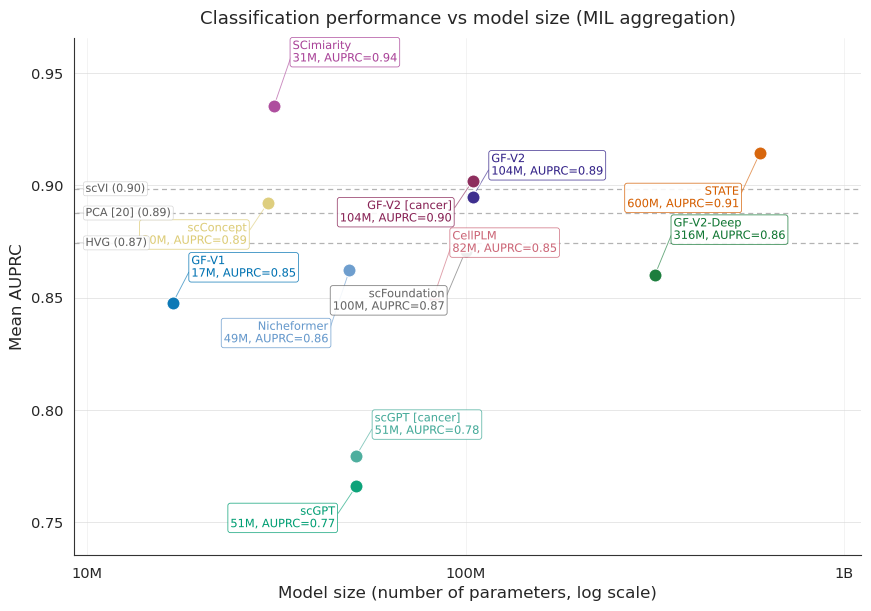

Saved plots/param_size_mil_publication.png
Saved plots/param_size_mil_publication.pdf
Saved plots/param_size_mil_publication.svg


In [24]:
nonzero = model_means[model_means['params'] > 0].sort_values('params').copy()
zero = model_means[model_means['params'] == 0].sort_values('mean_auprc', ascending=False).copy()

# Publication-friendly, colorblind-safe palette adapted from Okabe-Ito / Tol colors.
# Avoid very light yellow for points because it is difficult to see in print.
MODEL_COLORS = {
    'GF-V1': '#0072B2',          # blue
    'GF-V2': '#332288',          # indigo
    'GF-V2 [cancer]': '#882255', # wine
    'GF-V2-Deep': '#117733',     # green
    'scGPT': '#009E73',          # teal
    'scGPT [cancer]': '#44AA99', # cyan/teal, more readable than yellow
    'scFoundation': '#666666',   # neutral gray
    'CellPLM': '#CC6677',        # rose
    'SCimiarity': '#AA4499',     # purple
    'Nicheformer': '#6699CC',    # light blue
    'scConcept': '#DDCC77',      # muted gold
    'STATE': '#D55E00',          # vermillion
}
DEFAULT_COLOR = '#4D4D4D'


def format_params(value: float) -> str:
    """Compact parameter labels for ticks and annotations."""
    if value >= 1e9:
        return f'{value / 1e9:.1f}B'.replace('.0B', 'B')
    return f'{value / 1e6:.0f}M'


def repel_texts(ax, texts, xpad=6, ypad=4, max_iter=250):
    """Simple fallback label repulsion in display coordinates.

    This is used only when adjustText is not installed. It nudges overlapping
    labels vertically in opposite directions while preserving their arrow links.
    """
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    for _ in range(max_iter):
        moved = False
        bboxes = [t.get_window_extent(renderer=renderer).expanded(1.03, 1.12) for t in texts]
        for i in range(len(texts)):
            for j in range(i + 1, len(texts)):
                if not bboxes[i].overlaps(bboxes[j]):
                    continue
                yi = bboxes[i].y0 + bboxes[i].height / 2
                yj = bboxes[j].y0 + bboxes[j].height / 2
                direction = 1 if yi >= yj else -1
                for idx, sign in [(i, direction), (j, -direction)]:
                    x, y = texts[idx].get_position()
                    # Convert current data position to display, shift, then convert back.
                    x_disp, y_disp = ax.transData.transform((x, y))
                    x_new, y_new = ax.transData.inverted().transform((x_disp, y_disp + sign * ypad))
                    texts[idx].set_position((x_new, y_new))
                moved = True
        if not moved:
            break
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

    return texts


def repel_baseline_texts(texts, transform, ax, ypad=3, max_iter=120):
    """Nudge baseline labels vertically while keeping them in the left margin."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    for _ in range(max_iter):
        moved = False
        bboxes = [t.get_window_extent(renderer=renderer).expanded(1.06, 1.18) for t in texts]
        for i in range(len(texts)):
            for j in range(i + 1, len(texts)):
                if not bboxes[i].overlaps(bboxes[j]):
                    continue
                yi = bboxes[i].y0 + bboxes[i].height / 2
                yj = bboxes[j].y0 + bboxes[j].height / 2
                direction = 1 if yi >= yj else -1
                for idx, sign in [(i, direction), (j, -direction)]:
                    x_ax, y_data = texts[idx].get_position()
                    x_disp, y_disp = transform.transform((x_ax, y_data))
                    _, y_new = transform.inverted().transform((x_disp, y_disp + sign * ypad))
                    texts[idx].set_position((x_ax, y_new))
                moved = True
        if not moved:
            break
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

    return texts
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8.8, 6.2))

x_min = max(nonzero['params'].min() * 0.55, 1e6)
x_max = nonzero['params'].max() * 1.85
ypad = max(0.025, (model_means['mean_auprc'].max() - model_means['mean_auprc'].min()) * 0.18)
y_lo = model_means['mean_auprc'].min() - ypad
y_hi = model_means['mean_auprc'].max() + ypad

ax.set_xscale('log')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_lo, y_hi)

# Baseline horizontal lines first, so they stay visually behind model points.
# Labels are added later, aligned to each line in the left margin.
if not zero.empty:
    baseline_color = '#8A8A8A'
    for _, row in zero.iterrows():
        ax.axhline(
            y=row['mean_auprc'],
            linestyle=(0, (4, 3)),
            linewidth=0.9,
            color=baseline_color,
            alpha=0.65,
            zorder=1,
        )

# Scatter points.
for _, row in nonzero.iterrows():
    model = row['model_display']
    ax.scatter(
        row['params'],
        row['mean_auprc'],
        s=88,
        color=MODEL_COLORS.get(model, DEFAULT_COLOR),
        edgecolor='white',
        linewidth=0.8,
        alpha=0.95,
        zorder=4,
    )

# Initial label positions are deterministic but deliberately staggered to help the optimizer.
texts = []
for idx, (_, row) in enumerate(nonzero.reset_index(drop=True).iterrows()):
    model = row['model_display']
    color = MODEL_COLORS.get(model, DEFAULT_COLOR)
    x = row['params']
    y = row['mean_auprc']
    label = f"{model}\n{format_params(row['params'])}, AUPRC={row['mean_auprc']:.2f}"

    # Alternating x/y offsets reduce the chance that same-size models start on top of each other.
    x_factor = 1.12 if idx % 2 == 0 else 0.88
    y_offset = [0.014, -0.014, 0.024, -0.024][idx % 4]
    t = ax.text(
        x * x_factor,
        y + y_offset,
        label,
        fontsize=8.2,
        color=color,
        ha='left' if x_factor >= 1 else 'right',
        va='center',
        linespacing=1.05,
        bbox=dict(
            boxstyle='round,pad=0.22',
            facecolor='white',
            edgecolor=color,
            linewidth=0.55,
            alpha=0.88,
        ),
        path_effects=[pe.withStroke(linewidth=2.0, foreground='white', alpha=0.9)],
        zorder=5,
    )
    texts.append(t)

# Prefer adjustText if installed; otherwise use the built-in fallback above.
# Arrows are added only after labels are adjusted so pointers remain accurate.
try:
    from adjustText import adjust_text

    adjust_text(
        texts,
        ax=ax,
        expand=(1.12, 1.28),
        force_text=(0.40, 0.55),
        force_static=(0.18, 0.24),
        lim=600,
        only_move={'text': 'xy', 'static': 'xy', 'explode': 'xy', 'pull': 'xy'},
    )
except Exception:
    repel_texts(ax, texts)

# Draw arrows from the adjusted labels back to their points.
for text, (_, row) in zip(texts, nonzero.reset_index(drop=True).iterrows()):
    color = MODEL_COLORS.get(row['model_display'], DEFAULT_COLOR)
    ax.annotate(
        '',
        xy=(row['params'], row['mean_auprc']),
        xytext=text.get_position(),
        textcoords='data',
        arrowprops=dict(arrowstyle='-', color=color, lw=0.65, alpha=0.62, shrinkA=4, shrinkB=4),
        zorder=3,
    )

# Baseline labels: fixed left margin (axes x) + y on each dashed line (data y).
# Thin connectors tie labels back to the line when vertical repulsion nudges them.
if not zero.empty:
    from matplotlib.transforms import blended_transform_factory

    trans = blended_transform_factory(ax.transAxes, ax.transData)
    x_label = 0.014
    baseline_entries = []
    for _, row in zero.sort_values('mean_auprc', ascending=False).iterrows():
        t = ax.text(
            x_label,
            row['mean_auprc'],
            f"{row['model_display']} ({row['mean_auprc']:.2f})",
            transform=trans,
            fontsize=8.0,
            va='center',
            ha='left',
            color='#5F5F5F',
            bbox=dict(
                boxstyle='round,pad=0.18',
                facecolor='white',
                edgecolor='#CCCCCC',
                linewidth=0.45,
                alpha=0.9,
            ),
            path_effects=[pe.withStroke(linewidth=2.0, foreground='white', alpha=0.9)],
            zorder=6,
        )
        baseline_entries.append((t, row['mean_auprc']))

    repel_baseline_texts([t for t, _ in baseline_entries], trans, ax)

    for t, y_line in baseline_entries:
        ax.annotate(
            '',
            xy=(x_min, y_line),
            xytext=t.get_position(),
            xycoords=ax.transData,
            textcoords=trans,
            arrowprops=dict(
                arrowstyle='-',
                color='#AAAAAA',
                lw=0.55,
                alpha=0.7,
                shrinkA=0,
                shrinkB=2,
            ),
            zorder=2,
        )

# Axes and annotations.
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: format_params(x)))
ax.xaxis.set_minor_formatter(NullFormatter())

ax.set_xlabel('Model size (number of parameters, log scale)')
ax.set_ylabel('Mean AUPRC')
ax.set_title(f'Classification performance vs model size ({STRATEGY} aggregation)', pad=10)

ax.grid(axis='y', color='#D9D9D9', linewidth=0.7, alpha=0.65)
ax.grid(axis='x', which='major', color='#E6E6E6', linewidth=0.6, alpha=0.55)
ax.grid(axis='x', which='minor', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

out_base = PLOTS_DIR / f'param_size_{STRATEGY.lower()}_publication'
fig.savefig(out_base.with_suffix('.png'), dpi=450, bbox_inches='tight')
fig.savefig(out_base.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(out_base.with_suffix('.svg'), bbox_inches='tight')
plt.show()
print(f'Saved {out_base.with_suffix(".png")}')
print(f'Saved {out_base.with_suffix(".pdf")}')
print(f'Saved {out_base.with_suffix(".svg")}')


## Interpretation (MIL aggregation)

**Overall:** Classification AUPRC shows only a weak positive association with parameter count among foundation models (Pearson *r* ≈ 0.30). Model size alone does not predict performance.

**Top performers:** SCimiarity (~31M params; AUPRC 0.94) and STATE (~600M; 0.91) lead the field despite being very different in size. Several mid-sized models (30–100M) also perform strongly.

**Baselines:** Simple zero-parameter methods remain competitive. scVI (0.90) and PCA [20] (0.89) match or exceed many large pretrained models; HVG (0.87) is slightly lower but still within the same range as several foundation models.

**Geneformer / scGPT:** Within Geneformer, GF-V2 [cancer] (104M) outperforms GF-V1 (17M) and GF-V2-Deep (316M), so scaling Geneformer up does not monotonically improve results. scGPT models (~51M) underperform most other foundation models and all three baselines.

**Takeaway:** For this MIL-based classification benchmark, embedding quality and model choice matter more than parameter count. Strong performance is achievable with ~30M parameters, while some much larger models do not improve—and can reduce—AUPRC.

## Notes

The plot cell saves three publication-ready versions under `./plots/`:

- `param_size_<strategy>_publication.png` at 450 dpi;
- `param_size_<strategy>_publication.pdf`;
- `param_size_<strategy>_publication.svg`.

The notebook uses `adjustText` automatically when available. If it is not installed, the built-in `repel_texts` fallback still reduces label overlap without adding a new dependency.
